# AVG Testing

Jalankan setelah `AVG Training.ipynb` dan `AVG Extraction.ipynb` selesai. Notebook ini hanya melakukan inferensi pada official test CIFAR-10; tidak memilih atau melatih model.

## 1. Konfigurasi
Gunakan identitas run dan lokasi model hasil Training.

In [1]:
from pathlib import Path
import hashlib
import json

import joblib
import numpy as np
import tensorflow as tf

RUN_ID = "cifar10_7fitur_v1"
SEED = 30092026
VARIANT = "avg"
ROOT = Path.cwd().resolve()
OUT = ROOT / "outputs" / RUN_ID / VARIANT

for folder in ("model", "fitur", "laporan"):
    (OUT / folder).mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
if gpus:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Perangkat GPU:", gpus, "| Run:", RUN_ID)

I0000 00:00:1791470185.160443  175632 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791470185.197489  175632 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791470186.147166  175632 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Perangkat GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] | Run: cifar10_7fitur_v1


## 2. Konversi citra
Rumus identik dengan Training dan Extraction.

In [2]:
def prepare_images(x, variant):
    x = np.asarray(x, dtype=np.float32) / 255.0

    if variant == "rgb":
        return x
    if variant == "avg":
        return np.mean(x, axis=-1, keepdims=True, dtype=np.float32)
    if variant == "ntsc":
        weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
        return np.sum(x * weights, axis=-1, keepdims=True)

    raise ValueError(f"Varian tidak dikenal: {variant}")

## 3. Muat model terpilih
Periksa bahwa SVM berasal dari CNN dan run yang sama.

In [3]:
model_path = OUT / "model" / "cnn.keras"
assert model_path.exists() and (OUT / "model" / "svm.joblib").exists()
model_sha = hashlib.sha256(model_path.read_bytes()).hexdigest()
cnn = tf.keras.models.load_model(model_path, compile=False)
extractor = tf.keras.Model(cnn.input, cnn.get_layer("embedding").output)
payload = joblib.load(OUT / "model" / "svm.joblib")
assert payload["run_id"] == RUN_ID
assert payload["variant"] == VARIANT
assert payload["model_sha"] == model_sha
svm = payload["pipeline"]

I0000 00:00:1791470187.388873  175632 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1204 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 4. Muat official test
Hanya 10.000 gambar official test dipakai pada evaluasi akhir.

In [4]:
from tensorflow.keras.datasets import cifar10
(_, _), (x_test, y_test) = cifar10.load_data()
y_test = y_test.ravel().astype(np.int64)
assert x_test.shape == (10000, 32, 32, 3)

## 5. Ekstraksi fitur test
Gunakan CNN terpilih tanpa augmentasi training; simpan prediksi embedding per sampel.

In [5]:
test_features = extractor.predict(
    prepare_images(x_test, VARIANT),
    batch_size=128,
    verbose=1,
).astype(np.float32)
assert test_features.shape == (10000, 512) and np.isfinite(test_features).all()
np.savez_compressed(OUT / "fitur" / "test_features.npz", features=test_features,
                    y=y_test, indices=np.arange(10000),
                    run_id=RUN_ID, variant=VARIANT, model_sha=model_sha)

I0000 00:00:1791470190.199994  175719 cuda_dnn.cc:461] Loaded cuDNN version 92600
W0000 00:00:1791470190.655175  175719 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step


## 6. Prediksi SVM
Hasil official test diperoleh dari model yang sudah ditentukan sebelumnya.

In [6]:
pred = svm.predict(test_features)
assert pred.shape == y_test.shape

## 7. Metrik dan prediksi
Simpan accuracy, macro-F1, classification report, confusion matrix, dan prediksi per sampel.

In [7]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import matplotlib.pyplot as plt
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
metrics = {"run_id": RUN_ID, "variant": VARIANT, "accuracy": float(accuracy_score(y_test, pred)),
           "macro_f1": float(f1_score(y_test, pred, average="macro")),
           "classification_report": classification_report(
               y_test, pred, target_names=CLASS_NAMES, output_dict=True
           ),
           "confusion_matrix": confusion_matrix(y_test, pred).tolist()}
(OUT / "laporan" / "test_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
np.savez_compressed(
    OUT / "laporan" / "test_predictions.npz",
    indices=np.arange(len(y_test)),
    y_true=y_test,
    y_pred=pred,
)
print("Accuracy:", metrics["accuracy"], "Macro-F1:", metrics["macro_f1"])
print(classification_report(y_test, pred, target_names=CLASS_NAMES))

Accuracy: 0.8991 Macro-F1: 0.8989366927232503
              precision    recall  f1-score   support

    airplane       0.91      0.92      0.92      1000
  automobile       0.95      0.96      0.95      1000
        bird       0.86      0.84      0.85      1000
         cat       0.82      0.81      0.81      1000
        deer       0.86      0.89      0.87      1000
         dog       0.86      0.84      0.85      1000
        frog       0.91      0.92      0.92      1000
       horse       0.93      0.93      0.93      1000
        ship       0.94      0.94      0.94      1000
       truck       0.95      0.94      0.94      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## 8. Grafik confusion matrix
Simpan grafik yang memudahkan analisis kelas keliru.

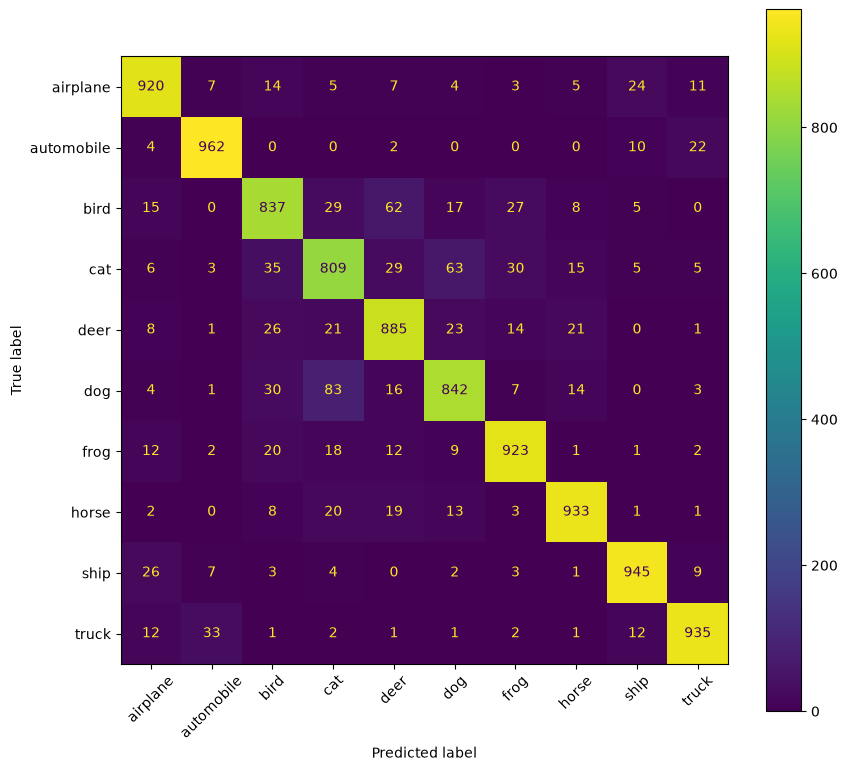

In [8]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=CLASS_NAMES, xticks_rotation=45
)
disp.figure_.set_size_inches(9, 8)
disp.figure_.tight_layout()
disp.figure_.savefig(OUT / "laporan" / "confusion_matrix.png", dpi=150)
plt.show()